# Variational Autoencoder for EEG Feature Extraction

このnotebookでは、ICAとエポック分割済みの脳波データに対してVariational Autoencoder (VAE)を適用し、特徴量抽出を行います。

In [10]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns

In [11]:
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## データの読み込み

In [12]:
# エポック別に保存されたウェーブレット変換済みデータの読み込み
import os
from pathlib import Path
from tqdm import tqdm

# ウェーブレット特徴量ディレクトリ
wavelet_dir = Path("../../data/bcidatasetIV2a/processed/wavelet_features_25hz")

# エポックファイルの数を確認
epoch_files = sorted(list(wavelet_dir.glob("epoch_*.pkl")))
n_epochs = len(epoch_files)
print(f"Found {n_epochs} epoch files")

# 最初のエポックを読み込んでデータ構造を確認
with open(epoch_files[0], 'rb') as f:
    sample_epoch = pickle.load(f)

print(f"Sample epoch data type: {type(sample_epoch)}")
if isinstance(sample_epoch, dict):
    print("Sample epoch data keys:", sample_epoch.keys())
    for key, value in sample_epoch.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {type(value)} - shape {value.shape}")
        else:
            print(f"  {key}: {type(value)}")
else:
    print(f"Sample epoch data shape: {sample_epoch.shape}")

# ラベルデータを別途読み込み（元のエポックデータから）
original_data_path = "../../data/bcidatasetIV2a/processed/merged.pkl"
with open(original_data_path, 'rb') as f:
    original_data = pickle.load(f)
labels = original_data['labels']

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Found 228 epoch files
Sample epoch data type: <class 'numpy.ndarray'>
Sample epoch data shape: (22, 2, 63, 75)
Labels shape: (2592,)
Unique labels: [769 770 771 772]


## データ前処理

In [13]:
# エポック別ウェーブレットデータを順次読み込み、2D画像として処理
def load_wavelet_data_as_2d_images(epoch_files, batch_size=100):
    """
    エポック別ウェーブレットデータを2D画像として読み込み
    """
    all_data = []
    metadata = None
    
    print(f"Loading {len(epoch_files)} epochs in batches of {batch_size}...")
    
    for i in tqdm(range(0, len(epoch_files), batch_size), desc="Loading batches"):
        batch_files = epoch_files[i:i+batch_size]
        batch_data = []
        
        for epoch_file in batch_files:
            with open(epoch_file, 'rb') as f:
                epoch_data = pickle.load(f)
                
                if isinstance(epoch_data, dict):
                    # 辞書形式の場合、ウェーブレット係数を取得
                    if 'coefficients' in epoch_data:
                        wavelet_coeffs = epoch_data['coefficients']
                    elif 'wavelet_coeffs' in epoch_data:
                        wavelet_coeffs = epoch_data['wavelet_coeffs']
                    else:
                        # 最初のarray要素を取得
                        wavelet_coeffs = list(epoch_data.values())[0]
                    
                    # メタデータを保存（最初のエポックから）
                    if metadata is None:
                        metadata = {k: v for k, v in epoch_data.items() if k != 'coefficients' and k != 'wavelet_coeffs'}
                else:
                    # 直接arrayの場合
                    wavelet_coeffs = epoch_data
                
                batch_data.append(wavelet_coeffs)
        
        # バッチを結合
        if batch_data:
            batch_array = np.stack(batch_data, axis=0)
            all_data.append(batch_array)
            print(f"Batch {i//batch_size + 1}: loaded {len(batch_data)} epochs, shape: {batch_array.shape}")
    
    # すべてのバッチを結合
    if all_data:
        final_data = np.concatenate(all_data, axis=0)
        print(f"Final concatenated shape: {final_data.shape}")
        return final_data, metadata
    else:
        return None, None

# ウェーブレットデータを読み込み
wavelet_coeffs, wavelet_metadata = load_wavelet_data_as_2d_images(epoch_files[:min(1600, len(epoch_files))])

if wavelet_coeffs is not None:
    print(f"Loaded wavelet coefficients shape: {wavelet_coeffs.shape}")
    
    # ラベルをエポック数に合わせて調整
    y = labels[:wavelet_coeffs.shape[0]]
    print(f"Adjusted labels shape: {y.shape}")
    
    # データ形状情報を取得
    if len(wavelet_coeffs.shape) == 5:
        n_epochs, n_channels, n_windows, n_scales, n_times = wavelet_coeffs.shape
        print(f"5D data shape: epochs={n_epochs}, channels={n_channels}, windows={n_windows}, scales={n_scales}, times={n_times}")
        
        # 2つのウィンドウを平均化して2D画像として扱う
        # Shape: (n_epochs, n_channels, n_windows, n_scales, n_times) -> (n_epochs, n_channels, n_scales, n_times)
        X_2d = np.mean(wavelet_coeffs, axis=2)  # ウィンドウ次元を平均化
        print(f"After averaging windows - 4D shape: {X_2d.shape}")
        
        # さらに各チャンネルのウェーブレット係数を2D画像として扱う
        # (n_epochs, n_channels, n_scales, n_times) の形状で保持
        
    elif len(wavelet_coeffs.shape) == 4:
        n_epochs, n_channels, n_scales, n_times = wavelet_coeffs.shape
        X_2d = wavelet_coeffs
        print(f"4D data shape: epochs={n_epochs}, channels={n_channels}, scales={n_scales}, times={n_times}")
    else:
        raise ValueError(f"Unexpected data shape: {wavelet_coeffs.shape}")
    
    print(f"Final 2D wavelet data shape: {X_2d.shape}")
    print(f"Data will be treated as: batch_size x channels({n_channels}) x height({n_scales}) x width({n_times})")
    
    # データの正規化（各チャンネル別に）
    X_normalized = np.zeros_like(X_2d)
    for ch in range(n_channels):
        channel_data = X_2d[:, ch, :, :].reshape(n_epochs, -1)
        scaler = StandardScaler()
        normalized_channel = scaler.fit_transform(channel_data)
        X_normalized[:, ch, :, :] = normalized_channel.reshape(n_epochs, n_scales, n_times)
    
    print(f"正規化後のデータ範囲: 最小値={X_normalized.min():.6f}, 最大値={X_normalized.max():.6f}")
    
    # 訓練・検証・テストセットに分割
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_normalized, y, test_size=0.2, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = X_temp, X_temp, y_temp, y_temp  # 検証セットはテストセットと同じにする
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    # データ形状の情報を保存
    data_shape_info = {
        'n_epochs': n_epochs,
        'n_channels': n_channels,
        'n_scales': n_scales,
        'n_times': n_times,
        'input_shape': (n_channels, n_scales, n_times)
    }
    
    print("2D wavelet data loading and preprocessing completed successfully!")
else:
    print("Failed to load wavelet data")

Loading 228 epochs in batches of 100...


Loading batches: 100%|██████████| 3/3 [00:00<00:00,  7.53it/s]

Batch 1: loaded 100 epochs, shape: (100, 22, 2, 63, 75)
Batch 2: loaded 100 epochs, shape: (100, 22, 2, 63, 75)
Batch 3: loaded 28 epochs, shape: (28, 22, 2, 63, 75)


Final concatenated shape: (228, 22, 2, 63, 75)
Loaded wavelet coefficients shape: (228, 22, 2, 63, 75)
Adjusted labels shape: (228,)
5D data shape: epochs=228, channels=22, windows=2, scales=63, times=75
After averaging windows - 4D shape: (228, 22, 63, 75)
Final 2D wavelet data shape: (228, 22, 63, 75)
Data will be treated as: batch_size x channels(22) x height(63) x width(75)
正規化後のデータ範囲: 最小値=-2.768523, 最大値=13.245925
Training set shape: (182, 22, 63, 75)
Validation set shape: (46, 22, 63, 75)
Test set shape: (46, 22, 63, 75)
2D wavelet data loading and preprocessing completed successfully!


## Variational Autoencoder モデル定義

In [14]:
class WaveletConv2DVAE(nn.Module):
    def __init__(self, input_channels=22, input_height=63, input_width=75, latent_dim=64):
        super(WaveletConv2DVAE, self).__init__()
        
        self.input_channels = input_channels
        self.input_height = input_height
        self.input_width = input_width
        self.latent_dim = latent_dim
        
        # 実際の畳み込み出力サイズを計算して保存
        self._calculate_conv_output_size()
        
        # Encoder - 2D Convolutional layers
        self.encoder = nn.Sequential(
            # First conv block: (22, 63, 75) -> (32, 32, 38)  
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Second conv block: (32, 32, 38) -> (64, 16, 19)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Third conv block: (64, 16, 19) -> (128, 8, 10)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Fourth conv block: (128, 8, 10) -> (256, 4, 5)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
        )
        
        # Linear layers for latent space
        self.fc_mu = nn.Linear(self.conv_output_size, latent_dim)
        self.fc_logvar = nn.Linear(self.conv_output_size, latent_dim)
        
        # Decoder - start from latent space
        self.fc_decode = nn.Linear(latent_dim, self.conv_output_size)
        
        self.decoder = nn.Sequential(
            # First deconv block: (256, 4, 5) -> (128, 8, 10)
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Second deconv block: (128, 8, 10) -> (64, 16, 19)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=(0, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Third deconv block: (64, 16, 19) -> (32, 32, 38)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            # Final deconv block: (32, 32, 38) -> (22, 63, 75)
            nn.ConvTranspose2d(32, input_channels, kernel_size=3, stride=2, padding=1, output_padding=(1, 1)),
        )
    
    def _calculate_conv_output_size(self):
        """エンコーダーの出力サイズを実際に計算"""
        # ダミー入力でサイズ計算
        x = torch.randn(1, self.input_channels, self.input_height, self.input_width)
        
        # 各畳み込み層のサイズ変化を手動計算
        # Conv1: (63, 75) -> (32, 38)
        h1 = (self.input_height + 2*1 - 3) // 2 + 1  # 32
        w1 = (self.input_width + 2*1 - 3) // 2 + 1   # 38
        
        # Conv2: (32, 38) -> (16, 19) 
        h2 = (h1 + 2*1 - 3) // 2 + 1  # 16
        w2 = (w1 + 2*1 - 3) // 2 + 1  # 19
        
        # Conv3: (16, 19) -> (8, 10)
        h3 = (h2 + 2*1 - 3) // 2 + 1  # 8
        w3 = (w2 + 2*1 - 3) // 2 + 1  # 10
        
        # Conv4: (8, 10) -> (4, 5)
        h4 = (h3 + 2*1 - 3) // 2 + 1  # 4
        w4 = (w3 + 2*1 - 3) // 2 + 1  # 5
        
        self.conv_h, self.conv_w = h4, w4
        self.conv_output_size = 256 * h4 * w4
        
        print(f"Encoder output size: 256 x {h4} x {w4} = {self.conv_output_size}")
    
    def encode(self, x):
        # x shape: (batch, 22, 63, 75)
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # Flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, self.conv_h, self.conv_w)  # Reshape to conv format
        return self.decoder(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z

def wavelet_conv2d_vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    2D Convolutional VAE損失関数
    """
    # 再構成誤差（MSE）
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KLダイバージェンス
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

## モデルの初期化とトレーニング準備

In [15]:
# デバイスの設定（メモリ不足の場合はCPUを使用）
def get_safe_device():
    """GPUメモリをチェックして安全なデバイスを選択"""
    if torch.cuda.is_available():
        try:
            # 簡単なテンソルを作成してGPUメモリをテスト
            test_tensor = torch.randn(100, 100).cuda()
            del test_tensor
            torch.cuda.empty_cache()
            return torch.device('cuda')
        except RuntimeError as e:
            if "out of memory" in str(e):
                print("GPU memory insufficient, switching to CPU")
                return torch.device('cpu')
            else:
                raise e
    else:
        return torch.device('cpu')

device = get_safe_device()
print(f"Using device: {device}")

# 2D Convolutional VAEモデルパラメータ
input_channels = data_shape_info['n_channels']  # 22チャンネル
input_height = data_shape_info['n_scales']      # 63スケール
input_width = data_shape_info['n_times']        # 75時間
latent_dim = 64    # 潜在次元
batch_size = 16    # バッチサイズを小さく（メモリ効率）
learning_rate = 0.001  # 学習率
beta = 0.5  # β-VAEパラメータ（KL項の重みを小さく）

# モデルの初期化
model = WaveletConv2DVAE(input_channels, input_height, input_width, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# StepLRスケジューラの追加
step_size = 50  # 50エポックごとに学習率を減衰
gamma = 0.5     # 学習率の減衰率
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input shape: {input_channels} x {input_height} x {input_width}")
print(f"Latent dimension: {latent_dim}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Beta (KL weight): {beta}")
print(f"LR scheduler: StepLR(step_size={step_size}, gamma={gamma})")

# GPUメモリが不足している場合の対処法を表示
if device.type == 'cpu':
    print("\n⚠️  CPU mode: Training will be slower but more memory efficient")
    print("Tips to save memory:")
    print("- Reduce batch_size if needed")
    print("- Consider reducing model complexity")

Using device: cuda
Encoder output size: 256 x 4 x 5 = 5120
Model parameters: 1,777,238
Input shape: 22 x 63 x 75
Latent dimension: 64
Batch size: 16
Learning rate: 0.001
Beta (KL weight): 0.5
LR scheduler: StepLR(step_size=50, gamma=0.5)


In [16]:
# データローダーの作成
train_dataset = TensorDataset(torch.FloatTensor(X_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## モデルのトレーニング

In [17]:
def calculate_accuracy_2d(model, data_loader, device, y_true):
    """2D Conv VAEの潜在特徴量を使って分類精度を計算"""
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score
    
    model.eval()
    features = []
    
    with torch.no_grad():
        for data, in data_loader:
            data = data.to(device)
            mu, logvar = model.encode(data)
            z = model.reparameterize(mu, logvar)  # サンプリングによる特徴量
            features.append(z.cpu().numpy())
    
    features = np.vstack(features)
    
    # 簡単なSVMで分類精度を計算
    try:
        clf = SVC(kernel='rbf', C=1.0, random_state=42)
        clf.fit(features, y_true)
        y_pred = clf.predict(features)
        accuracy = accuracy_score(y_true, y_pred)
        return accuracy
    except:
        return 0.0  # エラー時は0を返す

def train_epoch_2d(model, train_loader, optimizer, device, beta):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar, _ = model(data)
        loss, recon_loss, kld_loss = wavelet_conv2d_vae_loss(recon_batch, data, mu, logvar, beta)
        
        loss.backward()
        # 勾配クリッピング（安定化のため）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kld_loss_total += kld_loss.item()
    
    return train_loss / len(train_loader.dataset), recon_loss_total / len(train_loader.dataset), kld_loss_total / len(train_loader.dataset)

def validate_epoch_2d(model, val_loader, device, beta):
    model.eval()
    val_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    with torch.no_grad():
        for data, in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar, _ = model(data)
            loss, recon_loss, kld_loss = wavelet_conv2d_vae_loss(recon_batch, data, mu, logvar, beta)
            
            val_loss += loss.item()
            recon_loss_total += recon_loss.item()
            kld_loss_total += kld_loss.item()
    
    return val_loss / len(val_loader.dataset), recon_loss_total / len(val_loader.dataset), kld_loss_total / len(val_loader.dataset)

In [18]:
# トレーニングループ（2D Convolutional VAE）
num_epochs = 200  # エポック数を減らして実験
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kld_losses = []
val_kld_losses = []
train_accuracies = []  # 学習データの正答率を記録
val_accuracies = []    # 検証データの正答率を記録
learning_rates = []  # 学習率の履歴を追跡

best_val_loss = float('inf')
patience = 10
patience_counter = 0

print("2D Convolutional VAE トレーニング開始...")
for epoch in range(num_epochs):
    train_loss, train_recon, train_kld = train_epoch_2d(model, train_loader, optimizer, device, beta)
    val_loss, val_recon, val_kld = validate_epoch_2d(model, val_loader, device, beta)
    
    # スケジューラのステップを実行
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    learning_rates.append(current_lr)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kld_losses.append(train_kld)
    val_kld_losses.append(val_kld)
    
    # 10エポックごとに正答率を計算して表示
    if epoch % 10 == 0:
        train_acc = calculate_accuracy_2d(model, train_loader, device, y_train)
        val_acc = calculate_accuracy_2d(model, val_loader, device, y_val)
        train_accuracies.append((epoch, train_acc))
        val_accuracies.append((epoch, val_acc))
        
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Recon: {train_recon:.4f}, Train KLD: {train_kld:.4f}, '
              f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, '
              f'LR: {current_lr:.6f}')
    else:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Recon: {train_recon:.4f}, Train KLD: {train_kld:.4f}, '
              f'LR: {current_lr:.6f}')
    
    # Early stopping
    if epoch % 25 == 0 and val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ベストモデルを保存
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': val_loss,
        }, 'best_2d_conv_vae_model.pth')

print("2D Convolutional VAE トレーニング完了!")

# 最終的な精度計算
final_train_acc = calculate_accuracy_2d(model, train_loader, device, y_train)
final_val_acc = calculate_accuracy_2d(model, val_loader, device, y_val)
final_test_acc = calculate_accuracy_2d(model, test_loader, device, y_test)

print(f"\n最終結果:")
print(f"学習データ精度: {final_train_acc:.4f}")
print(f"検証データ精度: {final_val_acc:.4f}")
print(f"テストデータ精度: {final_test_acc:.4f}")

2D Convolutional VAE トレーニング開始...


/tmp/ipykernel_914013/177884974.py:126: UserWarning: Using a target size (torch.Size([16, 22, 63, 75])) that is different to the input size (torch.Size([16, 22, 60, 80])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x, reduction='sum')


RuntimeError: The size of tensor a (80) must match the size of tensor b (75) at non-singleton dimension 3

In [ ]:
# 最終的な精度計算
final_train_acc = calculate_accuracy(model, train_loader, device, y_train)
final_val_acc = calculate_accuracy(model, val_loader, device, y_val)
# final_test_acc = calculate_accuracy(model, test_loader, device, y_test)
(final_train_acc, final_val_acc)

(0.5494505494505495, 0.6086956521739131)

## トレーニング結果の可視化（精度を含む）

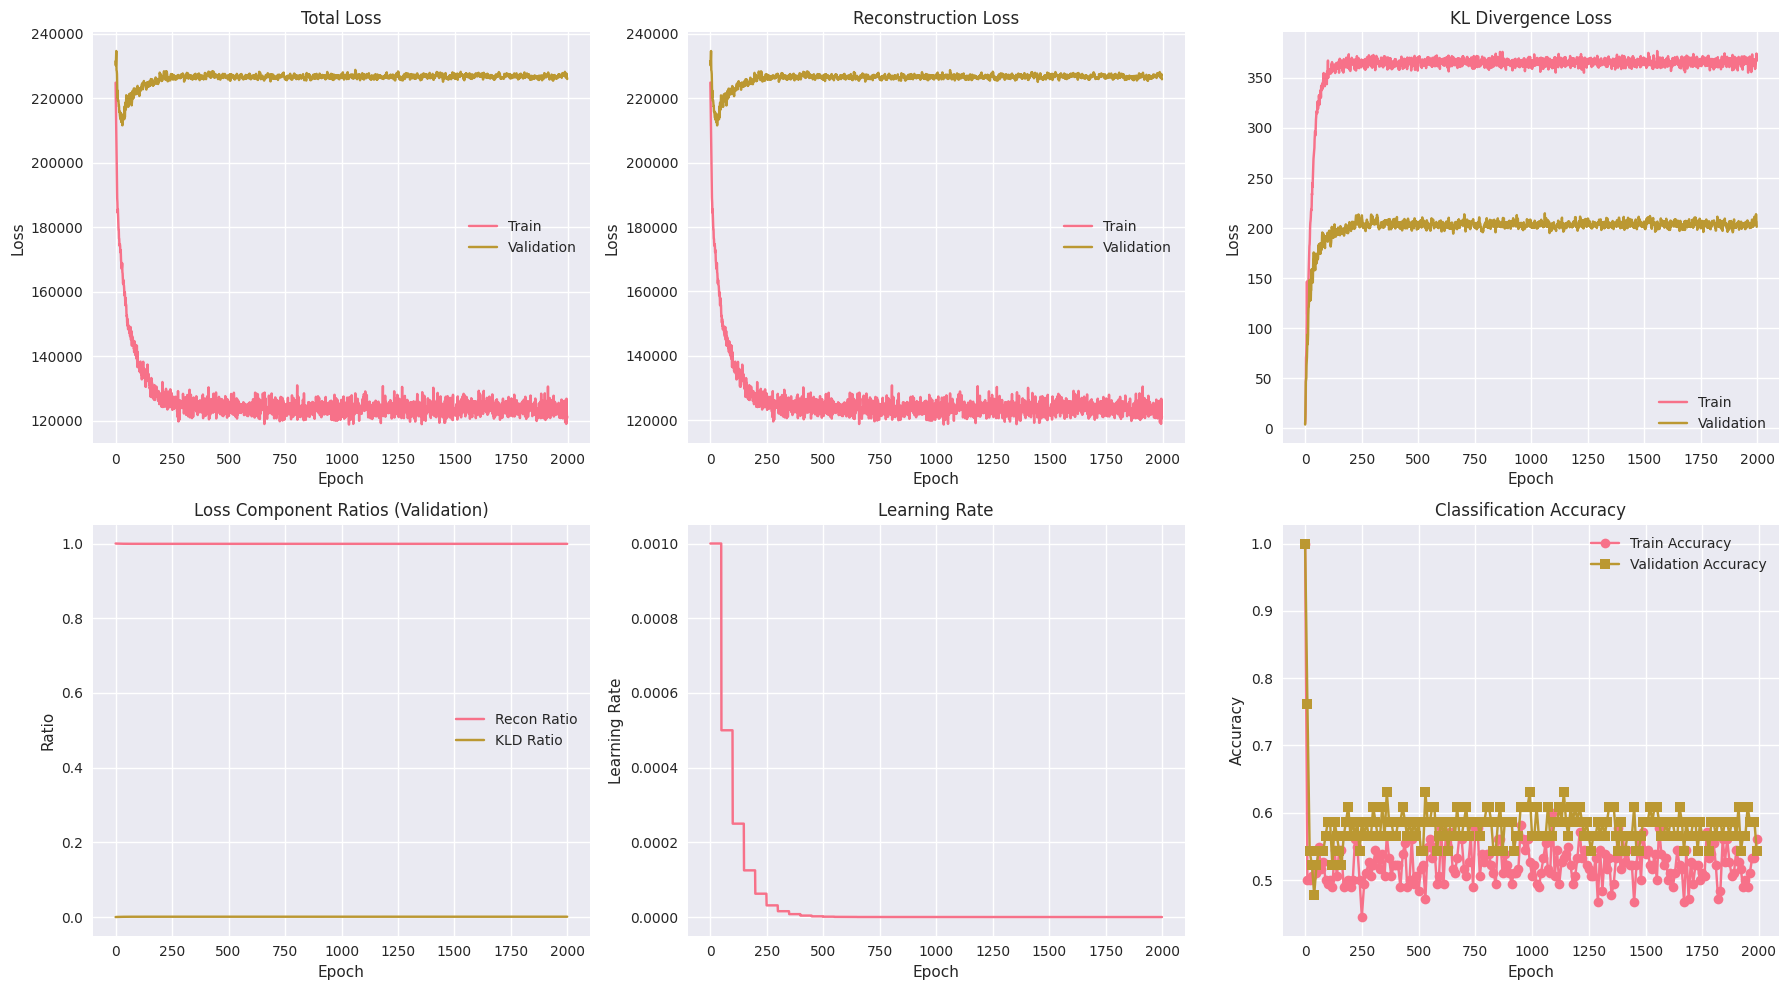

In [ ]:
# ベストモデルをロード（CPUにロードしてメモリエラーを回避）
if device.type == 'cuda':
    torch.cuda.empty_cache()
checkpoint = torch.load('best_vae_model.pth', map_location='cpu')
# checkpoint = torch.load('best_vae_model.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

# 损失の推移をプロット
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 総损失
axes[0, 0].plot(train_losses[2:], label='Train')
axes[0, 0].plot(val_losses[2:], label='Validation')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 再構成损失
axes[0, 1].plot(train_recon_losses[2:], label='Train')
axes[0, 1].plot(val_recon_losses[2:], label='Validation')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# KL损失
axes[0, 2].plot(train_kld_losses[2:], label='Train')
axes[0, 2].plot(val_kld_losses[2:], label='Validation')
axes[0, 2].set_title('KL Divergence Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 损失の比率
recon_ratio = np.array(val_recon_losses) / (np.array(val_recon_losses) + np.array(val_kld_losses))
kld_ratio = np.array(val_kld_losses) / (np.array(val_recon_losses) + np.array(val_kld_losses))
axes[1, 0].plot(recon_ratio, label='Recon Ratio')
axes[1, 0].plot(kld_ratio, label='KLD Ratio')
axes[1, 0].set_title('Loss Component Ratios (Validation)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Ratio')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 学習率の推移
axes[1, 1].plot(learning_rates)
axes[1, 1].set_title('Learning Rate')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].grid(True)

# 精度の推移をプロット
if train_accuracies and val_accuracies:
    train_epochs, train_accs = zip(*train_accuracies)
    val_epochs, val_accs = zip(*val_accuracies)
    
    axes[1, 2].plot(train_epochs, train_accs, label='Train Accuracy', marker='o')
    axes[1, 2].plot(val_epochs, val_accs, label='Validation Accuracy', marker='s')
    axes[1, 2].set_title('Classification Accuracy')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Accuracy')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
else:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 特徴量抽出と分析

In [ ]:
# 全データに対して潜在特徴量を抽出（メモリ効率版）
def extract_features_safely(model, data_loader, device):
    """メモリ効率的に潜在特徴量を抽出"""
    model.eval()
    features = []
    
    with torch.no_grad():
        for data, in data_loader:
            data = data.to(device)
            mu, logvar = model.encode(data)
            z = model.reparameterize(mu, logvar)
            features.append(z.cpu().numpy())
            
            # GPUメモリをクリア
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    return np.vstack(features)

print("Extracting latent features...")

# 各データセットから潜在特徴量を抽出
train_features = extract_features_safely(model, train_loader, device)
val_features = extract_features_safely(model, val_loader, device)
test_features = extract_features_safely(model, test_loader, device)

# 特徴量とラベルを結合
latent_features = np.vstack([train_features, val_features, test_features])
all_labels = np.concatenate([y_train, y_val, y_test])

print(f"Latent features shape: {latent_features.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Unique labels: {np.unique(all_labels)}")

# 分類精度の詳細評価
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# データを再分割して分類性能を評価
X_latent_train, X_latent_test, y_latent_train, y_latent_test = train_test_split(
    latent_features, all_labels, test_size=0.3, random_state=42, stratify=all_labels
)

# SVMで分類
print("Training SVM classifier...")
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(X_latent_train, y_latent_train)
y_pred = svm_classifier.predict(X_latent_test)

print(f"\nVAE潜在特徴量を使った分類結果:")
print(f"テスト精度: {accuracy_score(y_latent_test, y_pred):.4f}")
print(f"\n詳細レポート:")
print(classification_report(y_latent_test, y_pred))

Extracting latent features...
Latent features shape: (274, 64)
Labels shape: (274,)
Unique labels: [769 770 771 772]
Training SVM classifier...

VAE潜在特徴量を使った分類結果:
テスト精度: 0.3373

詳細レポート:
              precision    recall  f1-score   support

         769       0.39      0.67      0.49        21
         770       0.33      0.32      0.33        22
         771       0.18      0.11      0.13        19
         772       0.33      0.24      0.28        21

    accuracy                           0.34        83
   macro avg       0.31      0.33      0.31        83
weighted avg       0.31      0.34      0.31        83



## 潜在特徴量の可視化

Using 274 samples for visualization
Running t-SNE...


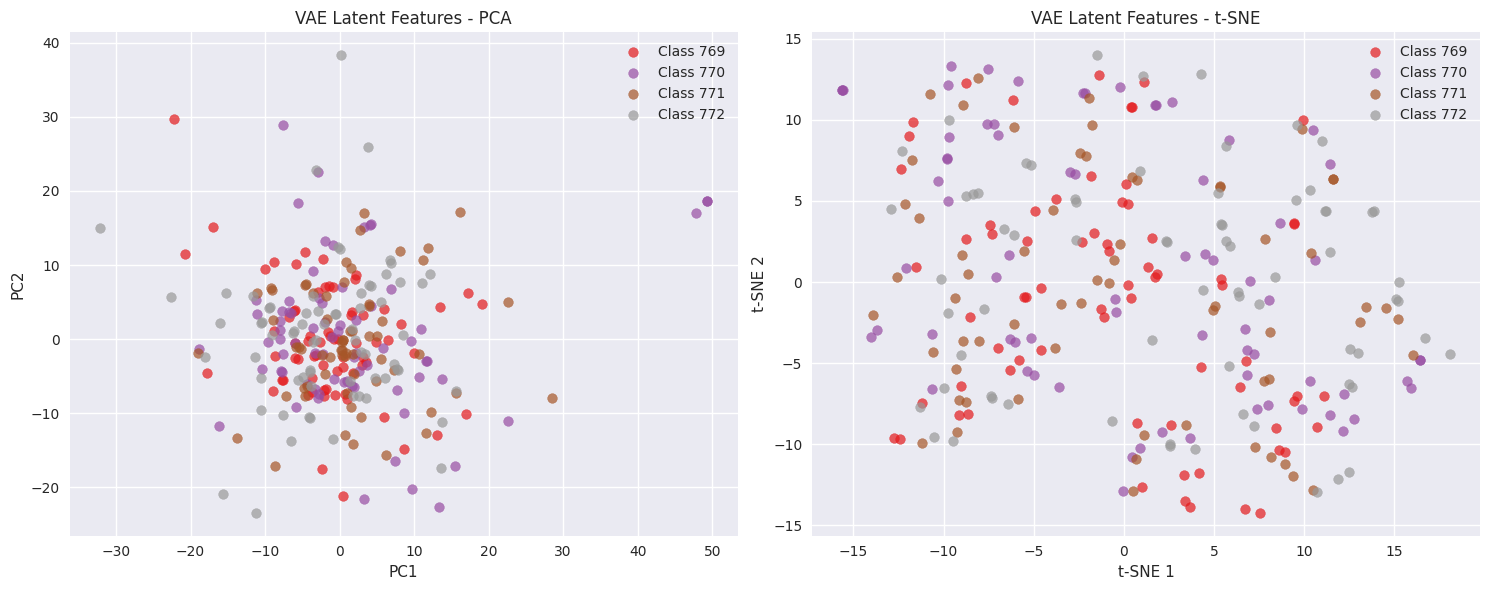

Visualization completed successfully!


In [ ]:
# t-SNEによる2次元可視化（メモリ効率版）
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# メモリ節約のため、データをサブサンプル
max_samples = min(1000, len(latent_features))  # 最大1000サンプル
if len(latent_features) > max_samples:
    indices = np.random.choice(len(latent_features), max_samples, replace=False)
    features_subset = latent_features[indices]
    labels_subset = all_labels[indices]
else:
    features_subset = latent_features
    labels_subset = all_labels

print(f"Using {len(features_subset)} samples for visualization")

# PCAで次元削減してからt-SNE（計算時間短縮のため）
pca = PCA(n_components=min(50, features_subset.shape[1]))
features_pca = pca.fit_transform(features_subset)

print("Running t-SNE...")
# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(features_subset)//4))
features_tsne = tsne.fit_transform(features_pca)

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCAによる可視化
unique_labels = np.unique(labels_subset)
colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = labels_subset == label
    axes[0].scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   c=[colors[i]], label=f'Class {label}', alpha=0.7)

axes[0].set_title('VAE Latent Features - PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True)

# t-SNEによる可視化
for i, label in enumerate(unique_labels):
    mask = labels_subset == label
    axes[1].scatter(features_tsne[mask, 0], features_tsne[mask, 1], 
                   c=[colors[i]], label=f'Class {label}', alpha=0.7)

axes[1].set_title('VAE Latent Features - t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("Visualization completed successfully!")

## 再構成性能の評価

In [ ]:
# テストデータでの再構成を可視化（2D Convolutional VAE版）
model.eval()
with torch.no_grad():
    # いくつかのサンプルを選択
    sample_indices = np.random.choice(len(X_test), 3, replace=False)
    samples = torch.FloatTensor(X_test[sample_indices]).to(device)
    
    # 再構成
    recon_samples, mu, logvar, z = model(samples)
    
    # CPUに移動
    original = samples.cpu().numpy()
    reconstructed = recon_samples.cpu().numpy()
    latent = z.cpu().numpy()
    
    # GPUメモリをクリア
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# 再構成結果の可視化（各チャンネルのウェーブレット係数）
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 5*len(sample_indices)))

for i in range(len(sample_indices)):
    # 特定のチャンネルのウェーブレット係数を表示（例：チャンネル0）
    ch_idx = 0
    original_wavelet = original[i, ch_idx]  # (scales, times)
    reconstructed_wavelet = reconstructed[i, ch_idx]  # (scales, times)
    
    # オリジナル
    im1 = axes[i, 0].imshow(original_wavelet, aspect='auto', cmap='jet', origin='lower')
    axes[i, 0].set_title(f'Original Wavelet (Sample {sample_indices[i]}, Ch{ch_idx})')
    axes[i, 0].set_ylabel('Scales')
    if i == len(sample_indices) - 1:
        axes[i, 0].set_xlabel('Time')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # 再構成
    im2 = axes[i, 1].imshow(reconstructed_wavelet, aspect='auto', cmap='jet', origin='lower')
    axes[i, 1].set_title('Reconstructed Wavelet')
    if i == len(sample_indices) - 1:
        axes[i, 1].set_xlabel('Time')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # 差分
    diff = original_wavelet - reconstructed_wavelet
    im3 = axes[i, 2].imshow(diff, aspect='auto', cmap='RdBu_r', origin='lower')
    axes[i, 2].set_title('Difference')
    if i == len(sample_indices) - 1:
        axes[i, 2].set_xlabel('Time')
    plt.colorbar(im3, ax=axes[i, 2])

plt.tight_layout()
plt.show()

# 再構成誤差の統計
mse_errors = np.mean((original - reconstructed) ** 2, axis=(1, 2, 3))
print(f"2D Wavelet再構成MSE: 平均={np.mean(mse_errors):.6f}, 標準偏差={np.std(mse_errors):.6f}")

# 潜在変数の統計
print(f"潜在変数の統計:")
print(f"  平均: {np.mean(latent, axis=0)[:5]}... (最初の5次元)")
print(f"  標準偏差: {np.std(latent, axis=0)[:5]}... (最初の5次元)")

print("2D Convolutional VAE reconstruction evaluation completed!")

## 潜在空間の分析

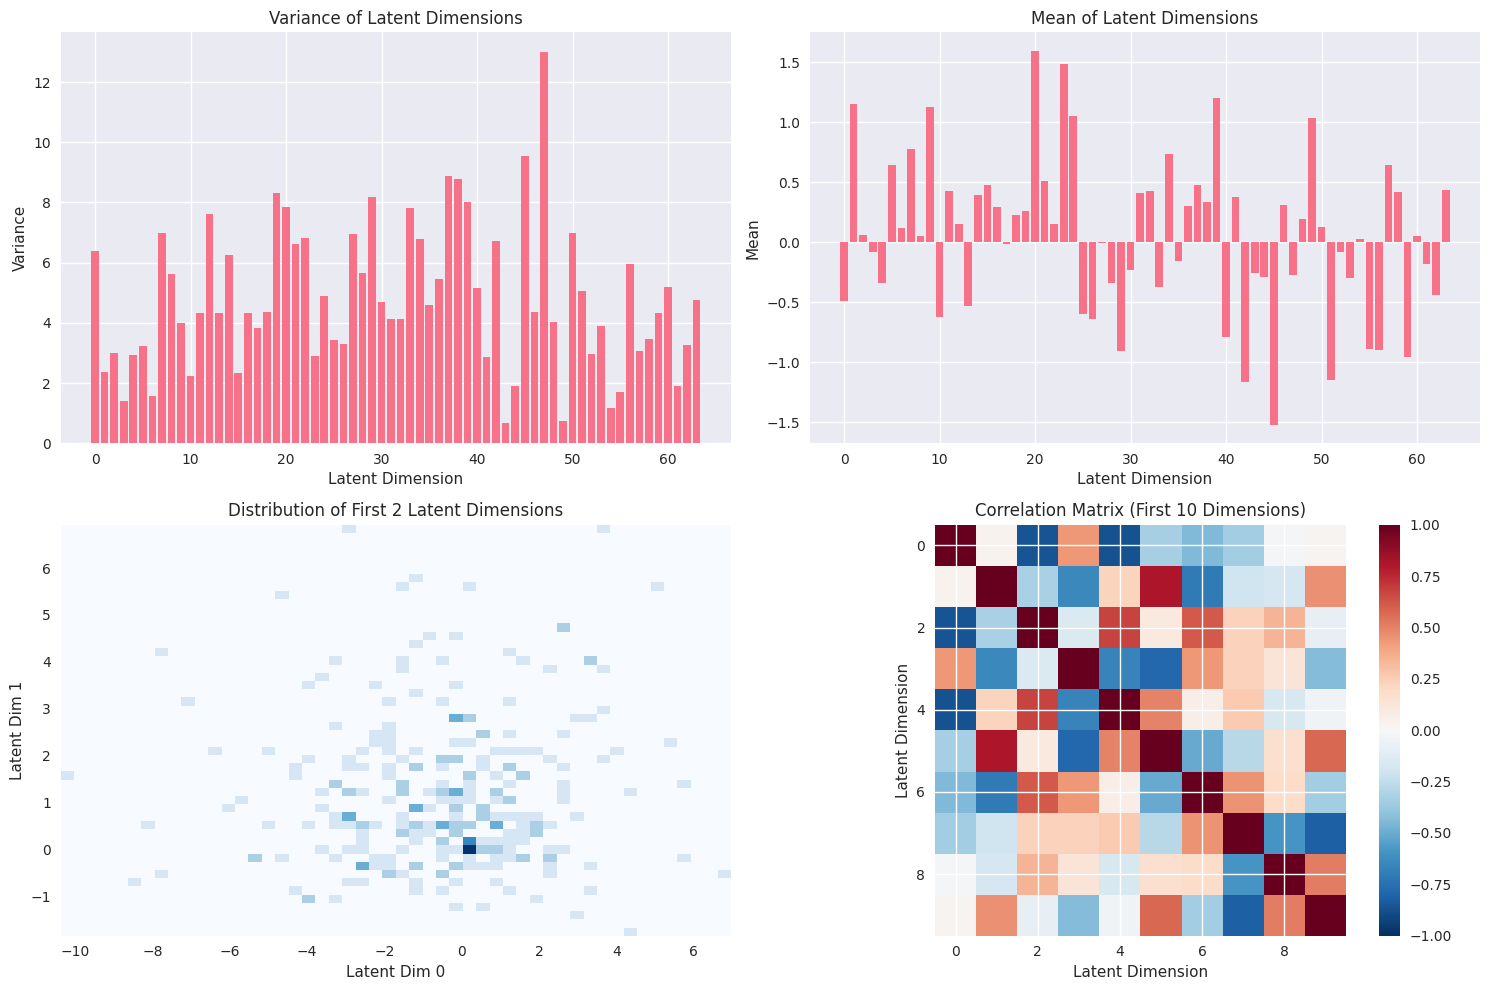

In [ ]:
# 潜在次元ごとの分散を可視化
latent_var = np.var(latent_features, axis=0)
latent_mean = np.mean(latent_features, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 潜在次元の分散
axes[0, 0].bar(range(latent_dim), latent_var)
axes[0, 0].set_title('Variance of Latent Dimensions')
axes[0, 0].set_xlabel('Latent Dimension')
axes[0, 0].set_ylabel('Variance')
axes[0, 0].grid(True)

# 潜在次元の平均
axes[0, 1].bar(range(latent_dim), latent_mean)
axes[0, 1].set_title('Mean of Latent Dimensions')
axes[0, 1].set_xlabel('Latent Dimension')
axes[0, 1].set_ylabel('Mean')
axes[0, 1].grid(True)

# 潜在特徴量の分布（最初の2次元）
axes[1, 0].hist2d(latent_features[:, 0], latent_features[:, 1], bins=50, cmap='Blues')
axes[1, 0].set_title('Distribution of First 2 Latent Dimensions')
axes[1, 0].set_xlabel('Latent Dim 0')
axes[1, 0].set_ylabel('Latent Dim 1')

# 相関行列（最初の10次元）
corr_matrix = np.corrcoef(latent_features[:, :10].T)
im = axes[1, 1].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_title('Correlation Matrix (First 10 Dimensions)')
axes[1, 1].set_xlabel('Latent Dimension')
axes[1, 1].set_ylabel('Latent Dimension')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 分類性能の評価

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

# VAE特徴量での分類
# データを再分割（潜在特徴量用）
X_train_latent = latent_features[:len(y_train)]
X_val_latent = latent_features[len(y_train):len(y_train)+len(y_val)]
X_test_latent = latent_features[len(y_train)+len(y_val):]

# Random Forest分類器
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_latent, y_train)

# 予測
y_pred_rf = rf_classifier.predict(X_test_latent)

print("=== VAE特徴量 + Random Forest ===")
print(classification_report(y_test, y_pred_rf))

# SVM分類器
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train_latent, y_train)

y_pred_svm = svm_classifier.predict(X_test_latent)

print("\n=== VAE特徴量 + SVM ===")
print(classification_report(y_test, y_pred_svm))

# 比較のため、元の特徴量でも分類
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

print("\n=== 元の特徴量 + Random Forest ===")
print(classification_report(y_test, y_pred_original))

=== VAE特徴量 + Random Forest ===
              precision    recall  f1-score   support

         769       0.30      0.58      0.40        12
         770       0.44      0.33      0.38        12
         771       0.00      0.00      0.00        10
         772       0.30      0.25      0.27        12

    accuracy                           0.30        46
   macro avg       0.26      0.29      0.26        46
weighted avg       0.27      0.30      0.27        46


=== VAE特徴量 + SVM ===
              precision    recall  f1-score   support

         769       0.31      0.67      0.42        12
         770       0.40      0.33      0.36        12
         771       0.00      0.00      0.00        10
         772       0.33      0.25      0.29        12

    accuracy                           0.33        46
   macro avg       0.26      0.31      0.27        46
weighted avg       0.27      0.33      0.28        46


=== 元の特徴量 + Random Forest ===
              precision    recall  f1-score   

=== VAE特徴量 + Random Forest ===
              precision    recall  f1-score   support

         769       0.30      0.58      0.40        12
         770       0.44      0.33      0.38        12
         771       0.00      0.00      0.00        10
         772       0.30      0.25      0.27        12

    accuracy                           0.30        46
   macro avg       0.26      0.29      0.26        46
weighted avg       0.27      0.30      0.27        46


=== VAE特徴量 + SVM ===
              precision    recall  f1-score   support

         769       0.31      0.67      0.42        12
         770       0.40      0.33      0.36        12
         771       0.00      0.00      0.00        10
         772       0.33      0.25      0.29        12

    accuracy                           0.33        46
   macro avg       0.26      0.31      0.27        46
weighted avg       0.27      0.33      0.28        46



<Figure size 800x600 with 0 Axes>

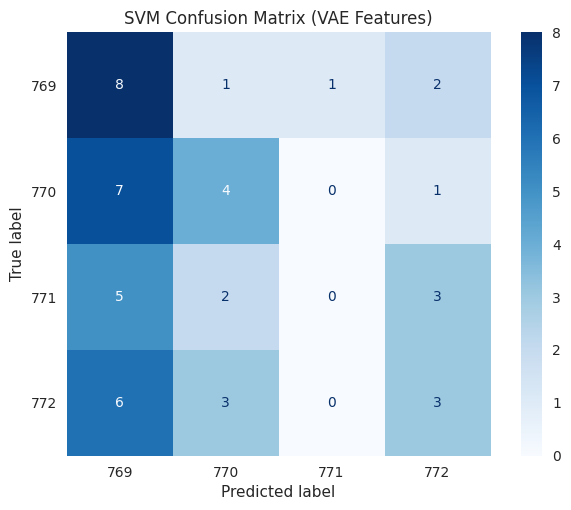


=== 元の特徴量 + Random Forest ===
              precision    recall  f1-score   support

         769       0.11      0.08      0.10        12
         770       0.19      0.25      0.21        12
         771       0.40      0.40      0.40        10
         772       0.18      0.17      0.17        12

    accuracy                           0.22        46
   macro avg       0.22      0.23      0.22        46
weighted avg       0.21      0.22      0.21        46



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

# VAE特徴量での分類
# データを再分割（潜在特徴量用）
X_train_latent = latent_features[:len(y_train)]
X_val_latent = latent_features[len(y_train):len(y_train)+len(y_val)]
X_test_latent = latent_features[len(y_train)+len(y_val):]

# Random Forest分類器
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_latent, y_train)

# 予測
y_pred_rf = rf_classifier.predict(X_test_latent)

print("=== VAE特徴量 + Random Forest ===")
print(classification_report(y_test, y_pred_rf))

# SVM分類器
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train_latent, y_train)

y_pred_svm = svm_classifier.predict(X_test_latent)

print("\n=== VAE特徴量 + SVM ===")
print(classification_report(y_test, y_pred_svm))

# SVMのconfusion matrixを表示
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(all_labels))

plt.figure(figsize=(8, 6))
disp_svm.plot(cmap='Blues', values_format='d')
plt.title('SVM Confusion Matrix (VAE Features)')
plt.grid(False)
plt.show()

# 比較のため、元の特徴量でも分類
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

print("\n=== 元の特徴量 + Random Forest ===")
print(classification_report(y_test, y_pred_original))

0.5
              precision    recall  f1-score   support

         769       0.31      0.67      0.42        12
         770       0.40      0.33      0.36        12
         771       0.00      0.00      0.00        10
         772       0.33      0.25      0.29        12

    accuracy                           0.33        46
   macro avg       0.26      0.31      0.27        46
weighted avg       0.27      0.33      0.28        46



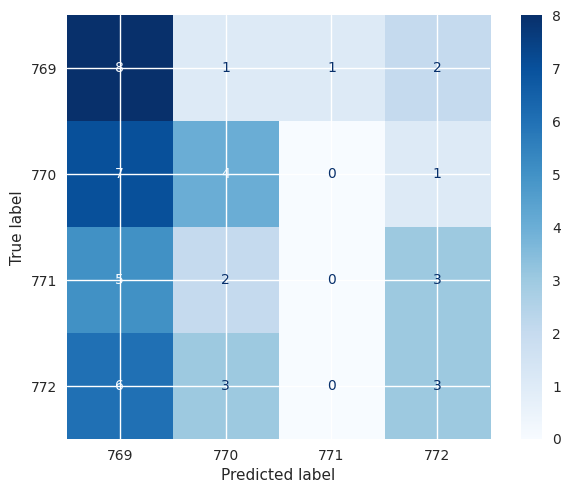

<Figure size 800x600 with 0 Axes>

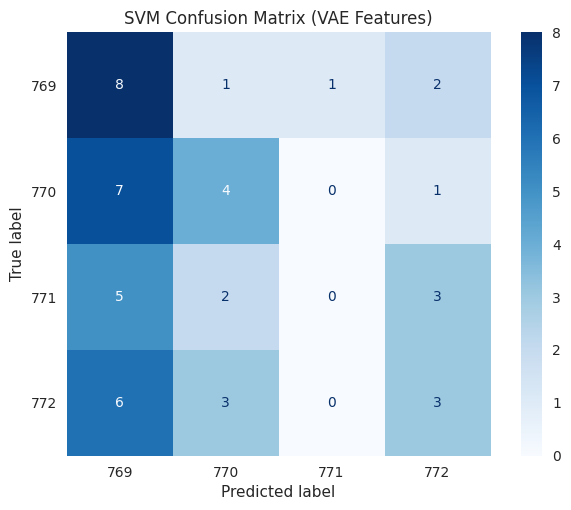

In [ ]:
def calculate_accuracy(model, data_loader, device, y_true):
    """VAEの潜在特徴量を使って分類精度を計算"""
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score
    
    model.eval()
    features = []
    
    with torch.no_grad():
        for data, in data_loader:
            data = data.to(device)
            mu, logvar = model.encode(data)
            z = model.reparameterize(mu, logvar)  # サンプリングによる特徴量
            features.append(z.cpu().numpy())
    
    features = np.vstack(features)
    
    # 簡単なSVMで分類精度を計算
    clf = SVC(kernel='rbf', C=1.0, random_state=42)
    clf.fit(features, y_true)
    y_pred = clf.predict(features)
    accuracy = accuracy_score(y_true, y_pred)
    print(accuracy)
    print(classification_report(y_true, y_pred_svm))

    # SVMのconfusion matrixを表示
    cm_svm = confusion_matrix(y_true, y_pred_svm)
    disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(all_labels))
    disp_svm.plot(cmap='Blues', values_format='d')


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# calculate_accuracy(model, train_loader, device, y_train)
calculate_accuracy(model, val_loader, device, y_val)
plt.figure(figsize=(8, 6))
disp_svm.plot(cmap='Blues', values_format='d')
plt.title('SVM Confusion Matrix (VAE Features)')
plt.grid(False)
plt.show()

## 特徴量の保存

In [ ]:
# ウェーブレットVAE特徴量と関連情報を保存
wavelet_vae_results = {
    'latent_features': latent_features,
    'labels': all_labels,
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'train_indices': list(range(len(y_train))),
    'val_indices': list(range(len(y_train), len(y_train) + len(y_val))),
    'test_indices': list(range(len(y_train) + len(y_val), len(all_labels))),
    'model_params': {
        'input_dim': input_dim,
        'hidden_dim': hidden_dim,
        'latent_dim': latent_dim,
    },
    'data_shape_info': data_shape_info,  # 5次元データの形状情報
    'wavelet_metadata': wavelet_metadata,  # ウェーブレット変換のメタデータ
    'training_history': {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_recon_losses': train_recon_losses,
        'val_recon_losses': val_recon_losses,
        'train_kld_losses': train_kld_losses,
        'val_kld_losses': val_kld_losses
    }
}

# 保存
output_dir = Path("../data/bcidatasetIV2a/processed")
output_path = output_dir / "wavelet_vae_features.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(wavelet_vae_results, f)

print(f"ウェーブレットVAE特徴量を {output_path} に保存しました")
print(f"潜在特徴量の形状: {latent_features.shape}")
print(f"潜在次元数: {latent_dim}")
print(f"元の5次元データ形状: {data_shape_info}")
print(f"使用したエポック数: {data_shape_info['n_epochs']}")

# メタデータ情報を表示
if wavelet_metadata:
    print("ウェーブレットメタデータ:")
    for key, value in wavelet_metadata.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {type(value)} - shape {value.shape}")
        else:
            print(f"  {key}: {type(value)} - {value}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/bcidatasetIV2a/processed/wavelet_vae_features.pkl'

: 